## 7ª Tarefa de Oficina de Modelagem e Simulação
 
**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 11 de abril de 2026  

---

### Descrição
Exercícios computacionais

In [5]:
"""
    1. Dadas as funções de transferência H1(s) = (1)/(s+2) e 
    H2(s) = (3)/(s+4), pede-se:

    a. Conecte os modelos em série
    b. Conecte os modelos em paralelo
    c. Conecte os modelos em malha fechada, com H1(s) no ramo direto 
    e H2(s) na realimentação
    d. Idem ao exercício 1c, mas considerando realimentação positiva
    e. Repita o exercício 1c usando o comando feedback
    f. Repita o exercício 1c usando o comando connect
"""
import control as ctrl
import matplotlib.pyplot as plt

H1 = ctrl.tf([1], [1, 2], inputs='e', outputs='y')
H2 = ctrl.tf([3], [1, 4], inputs='y', outputs='b')

# Item (a)
em_serie = H1 * H2
print("a)H1 em série com H2:", em_serie)

# Item (b)
em_paralelo = H1 + H2
print("b)H1 em paralelo com H2:", em_paralelo)

# Item (c)
malha_fechada = H1 / (1 + H1 * H2)
print("c)H1 em malha fechada com H2 na realimentação:", malha_fechada)

# Item (d)
malha_fechada_positiva = H1 / (1 - H1 * H2)
print("d)H1 em malha fechada com H2 na realimentação positiva:", malha_fechada_positiva)

# Item (e)
malha_fechada_feedback = ctrl.feedback(H1, H2)
print("e)H1 em malha fechada usando feedback:", malha_fechada_feedback)

# Item (f)
sumblk = ctrl.summing_junction(
    inputs=['r', '-b'],
    output='e'
)
malha_fechada_connect = ctrl.interconnect(
    [H1, H2, sumblk],
    inputs='r',
    outputs='y'
)
print("f)H1 em malha fechada usando connect:", malha_fechada_connect)

a)H1 em série com H2: <TransferFunction>: sys[72]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        3
  -------------
  s^2 + 6 s + 8
b)H1 em paralelo com H2: <TransferFunction>: sys[73]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    4 s + 10
  -------------
  s^2 + 6 s + 8
c)H1 em malha fechada com H2 na realimentação: <TransferFunction>: sys[77]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       s^2 + 6 s + 8
  -----------------------
  s^3 + 8 s^2 + 23 s + 22
d)H1 em malha fechada com H2 na realimentação positiva: <TransferFunction>: sys[82]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       s^2 + 6 s + 8
  -----------------------
  s^3 + 8 s^2 + 17 s + 10
e)H1 em malha fechada usando feedback: <TransferFunction>: sys[83]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      s + 4
  --------------
  s^2 + 6 s + 11
f)H1 em malha fechada usando connect: <LinearICSystem>: sys[87]
Inputs (1): ['r']
Outputs (1): ['y']
States (2): ['sys[70]_x[0]', 'sys[71]_x[0]']

Subsystems (3):
 * <State

a) Função de transferência para K=7: <TransferFunction>: sys[167]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        7
  -------------
  s^2 + 8 s + 7
b) Função de transferência para K=16: <TransferFunction>: sys[172]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        16
  --------------
  s^2 + 8 s + 16
c) Função de transferência para K=80: <TransferFunction>: sys[177]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        80
  --------------
  s^2 + 8 s + 80


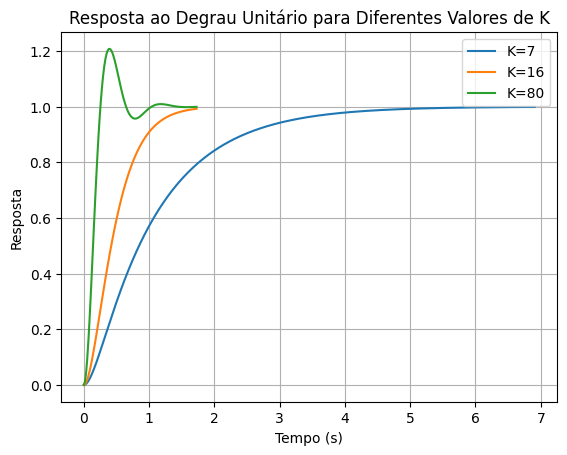

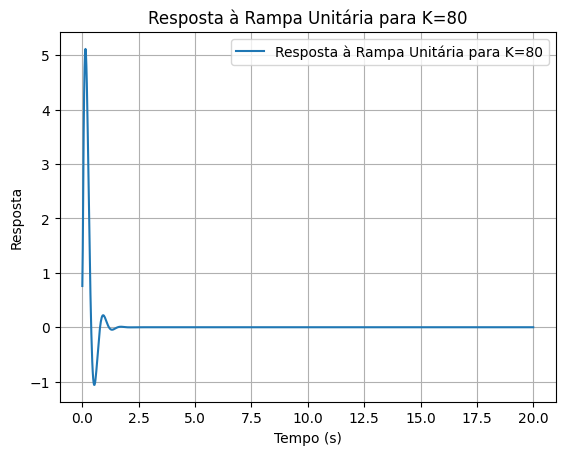

In [9]:
"""
    2. Baseado no sistema realimentado da Figura 7 com G(s) = K/(s(s+8)) 
    e H(s) = 1, determine a função de transferência para cada um dos seguintes casos:
    
    a. K = 7
    b. K = 16
    c. K = 80
    Comente a respeito da resposta ao degrau unitário em cada um dos casos. Trace
    as respostas no mesmo gráfico usando plot e hold.
    Adicionalmente:
    d. Encontre a resposta à rampa unitária quando K = 80. Note que a resposta à 
    rampa unitária á equivalente `a derivada da resposta ao degrau unitária.
"""
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

# Item (a)
ka = 7
Ga = ctrl.tf([ka],[1, 8, 0])
Ha = ctrl.tf([1], [1])

ramo_direto_a = Ga * Ha
malha_fechada_a = ctrl.feedback(ramo_direto_a, 1)
print("a) Função de transferência para K=7:", malha_fechada_a)

# Item (b)
kb = 16
Gb = ctrl.tf([kb],[1, 8, 0])
Hb = ctrl.tf([1], [1])
ramo_direto_b = Gb * Hb
malha_fechada_b = ctrl.feedback(ramo_direto_b, 1)
print("b) Função de transferência para K=16:", malha_fechada_b)

# Item (c)
kc = 80
Gc = ctrl.tf([kc],[1, 8, 0])
Hc = ctrl.tf([1], [1])
ramo_direto_c = Gc * Hc
malha_fechada_c = ctrl.feedback(ramo_direto_c, 1)
print("c) Função de transferência para K=80:", malha_fechada_c)

"""
    Observa-se que o aumento do ganho K torna o sistema mais rápido, reduzindo o tempo de subida da 
    resposta ao degrau. Entretanto, ganhos elevados reduzem o amortecimento do sistema, provocando 
    maior overshoot e oscilações antes da estabilização. Para K=7, a resposta é lenta e bem amortecida; 
    para K=16, o sistema torna-se mais rápido; já para K=80, observa-se comportamento oscilatório 
    significativo.
"""

# Respostas ao degrau unitário
ta, y_a = ctrl.step_response(malha_fechada_a)
tb, y_b = ctrl.step_response(malha_fechada_b)
tc, y_c = ctrl.step_response(malha_fechada_c)

plt.figure()
plt.plot(ta, y_a, label='K=7')
plt.plot(tb, y_b, label='K=16')
plt.plot(tc, y_c, label='K=80')
plt.title('Resposta ao Degrau Unitário para Diferentes Valores de K')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.legend()
plt.grid()
plt.show()

# Item (d)
t_rampa, y_rampa = ctrl.step_response(malha_fechada_c, T=np.linspace(0, 20, 1000))
resposta_rampa = np.gradient(y_rampa, t_rampa)
plt.figure()
plt.plot(t_rampa, resposta_rampa, label='Resposta à Rampa Unitária para K=80')
plt.title('Resposta à Rampa Unitária para K=80')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.legend()
plt.grid()
plt.show()




In [ ]:
"""
    3. Para o exemplo do dois tanques interligados, obtenha as seguintes funções de transferência
    utilizando redução de blocos

    a. H2(s)/H1(s)    
    b. H2(s)/Qi(s)
    c. H1(s)/Qi(s)

    Resolução se encontra no .jpg anexado junto ao jupyter notebook.
"""

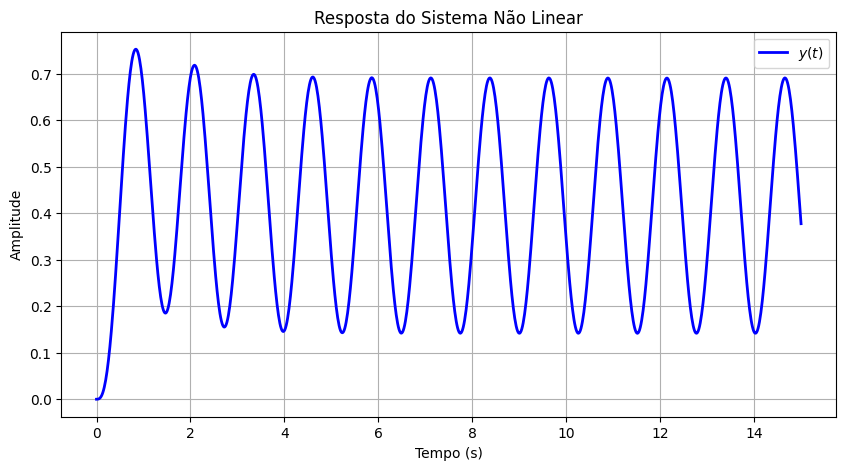

In [10]:
"""
    5. Seja um sistema não linear descrito pela equação diferencial:
    y'' + 3y' + e^(-t)y = 8sen(5t)
    Pede-se:

    a) Construa um diagrama de blocos que represente o sistema.
    b) Simule o comportamento do sistema para condições iniciais nulas.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def sistema_nao_linear(t, x):
    # x[0] é y (ou x1)
    # x[1] é y_ponto (ou x2)
    
    x1 = x[0]
    x2 = x[1]
    
    # As equações de estado
    dx1_dt = x2
    dx2_dt = 8 * np.sin(5 * t) - 3 * x2 - np.exp(-t) * x1
    
    return [dx1_dt, dx2_dt]

x0 = [0.0, 0.0]

t_span = (0, 15)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

solucao = solve_ivp(sistema_nao_linear, t_span, x0, t_eval=t_eval)

t = solucao.t
y = solucao.y[0] # Posição
y_ponto = solucao.y[1] # Velocidade

plt.figure(figsize=(10, 5))
plt.plot(t, y, label=r'$y(t)$', color='blue', linewidth=2)
plt.title('Resposta do Sistema Não Linear')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

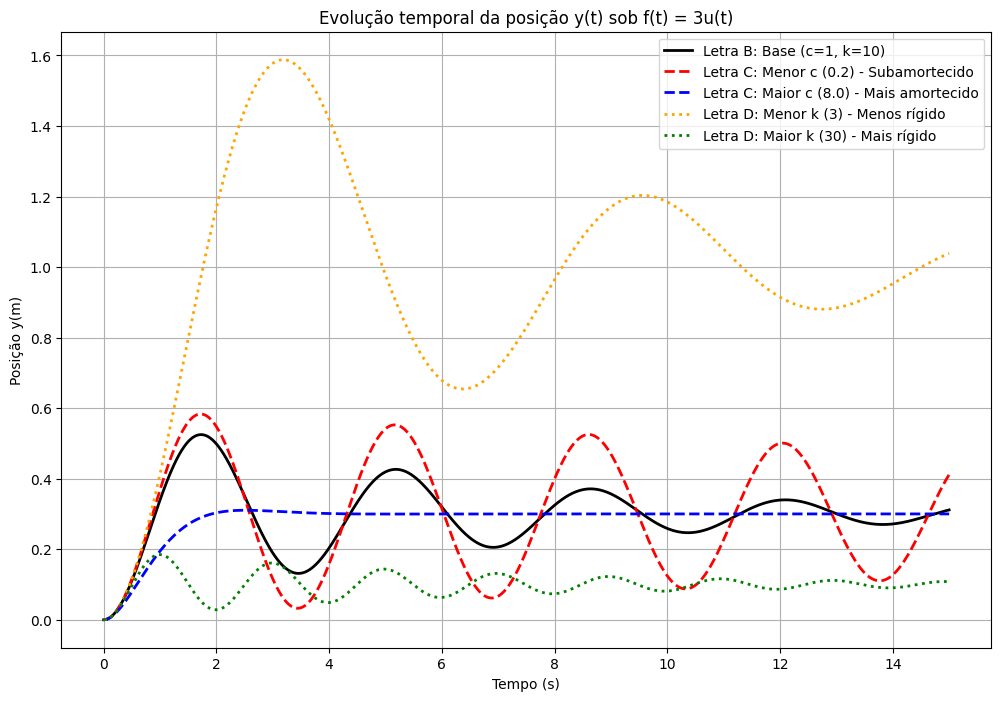

In [11]:
"""
    Considere o sistema massa-mola-amortecedor apresentado no Tutorial 2, o qual é reproduzido
    na Figura 18 e cujo modelo matemático em torno do ponto de equilíbrio estático é:

    my'' + cy' + ky = f(t)

    Tomando m = 3 kg, c = 1 Ns/m e k = 10 N/m, pede-se:
    a) Construa um diagrama de blocos que represente o sistema.
    b) Simule o sistema para f (t) = 3u(t) e apresente a evolução da posição vertical da
    massa m ao longo do tempo.
    c) Repita o item anterior, mantendo k = 10 N/m, mas escolha dois valores distintos
    para c, um maior e outro menor. O que é possível observar em cada caso?
    d) Repita o item anterior, matendo c = 1 Ns/m, mas escolha dois valores distintos para
    k, um maior e outro menor. O que é possível observar em cada caso?
"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Parâmetros base do problema
m = 3
c_base = 1
k_base = 10
amplitude_degrau = 3

def simular_e_plotar(m, c, k, label, color, linestyle='-'):
    """
    Função auxiliar que cria a função de transferência, 
    simula a resposta ao degrau e plota o resultado.
    """
    # Define a FT: 1 / (m*s^2 + c*s + k)
    sistema = signal.TransferFunction([1], [m, c, k])
    
    # Vetor de tempo de 0 a 15 segundos
    t_in = np.linspace(0, 15, 1000)
    
    # Simula a resposta ao degrau unitário e multiplica pela amplitude real da força
    t, y = signal.step(sistema, T=t_in)
    y_final = y * amplitude_degrau
    
    plt.plot(t, y_final, label=label, color=color, linestyle=linestyle, linewidth=2)

plt.figure(figsize=(12, 8))

# B) Simulação do sistema original
simular_e_plotar(m, c_base, k_base, f'Letra B: Base (c={c_base}, k={k_base})', 'black')

# C) Variando o amortecimento (c)
simular_e_plotar(m, 0.2, k_base, 'Letra C: Menor c (0.2) - Subamortecido', 'red', '--')
simular_e_plotar(m, 8.0, k_base, 'Letra C: Maior c (8.0) - Mais amortecido', 'blue', '--')

# D) Variando a rigidez (k)
simular_e_plotar(m, c_base, 3, 'Letra D: Menor k (3) - Menos rígido', 'orange', ':')
simular_e_plotar(m, c_base, 30, 'Letra D: Maior k (30) - Mais rígido', 'green', ':')

plt.title('Evolução temporal da posição y(t) sob f(t) = 3u(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição y(m)')
plt.grid(True)
plt.legend()
plt.show()